# LD-block coherence vs BigLD CLQcut (Chr1, non-missing map: call-rate ≥ 0.9, all-class)

For each candidate block map (BigLD fine-split at r² cutoff **CLQcut = 0.5 / 0.7 / 0.9**),
each block is summarized by **PC1** of its variants' allele frequencies across the 355 gen9
pools. **PC1 variance-explained (PC1-VE)** = fraction of the block's co-movement captured by
one axis = how much the block behaves as a *single haplotype* (a clean test unit).
Higher CLQcut = stricter LD grouping = smaller, more coherent blocks.

Target (the "coherence-first" criterion): median PC1-VE ≳ 0.7.
*(PC1-VE is measured on noisy small-pool gen9 AF, which caps it somewhat.)*

In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({"figure.dpi":110,"font.size":11,"axes.grid":True,"grid.alpha":.3})
# per-block PC1-VE by CLQcut on the NON-MISSING (min-called-frac 0.9) Chr1 map
MD90 = "/global/scratch/users/tbellg/kmate/results/grenenet_gea/blocks_mcf90"
_p=[]
for c in [0.5,0.7,0.9]:
    _f=f"{MD90}/chr1_frontier_blocks_clq{c}.csv"
    if os.path.exists(_f):
        b=pd.read_csv(_f); _p.append(pd.DataFrame({"clqcut":c,"pc1_ve":b.block_ve,"n_variants":b.nvar}))
df = pd.concat(_p, ignore_index=True) if _p else pd.DataFrame(columns=["clqcut","pc1_ve","n_variants"])
print("CLQcuts available:", sorted(df.clqcut.unique()) if len(df) else "none yet (clq_sweep job running)")
levels = sorted(df.clqcut.unique()) if len(df) else [0.9]   # adapts while clq_sweep job runs
colors = {0.5:"#4C72B0",0.7:"#DD8452",0.9:"#55A868"}
summary = df.groupby("clqcut").agg(
    n_blocks=("pc1_ve","size"),
    median_VE=("pc1_ve","median"),
    frac_VE_ge_0p7=("pc1_ve",lambda x:(x>=0.7).mean()),
    median_size=("n_variants","median")).round(3)
summary

CLQcuts available: [0.5, 0.7, 0.9]


,n_blocks,median_VE,frac_VE_ge_0p7,median_size
clqcut,,,,
0.5,8004,0.656,0.439,10.0
0.7,10864,0.722,0.527,9.0
0.9,15789,0.825,0.656,7.0


## 1. PC1-VE distribution per CLQcut (violin + median)

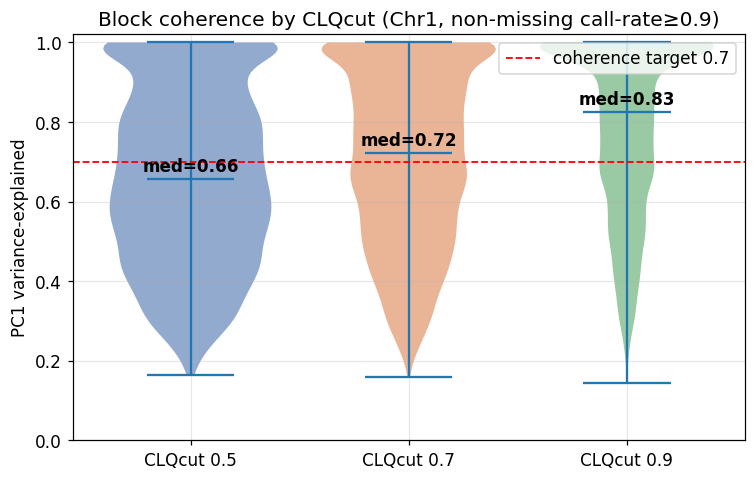

In [2]:
fig, ax = plt.subplots(figsize=(7,4.5))
data = [df[df.clqcut==c].pc1_ve.dropna().values for c in levels]
parts = ax.violinplot(data, positions=range(len(levels)), showmedians=True, widths=0.8)
for i,b in enumerate(parts['bodies']):
    b.set_facecolor(colors[levels[i]]); b.set_alpha(.6)
for i,c in enumerate(levels):
    m = np.nanmedian(df[df.clqcut==c].pc1_ve)
    ax.text(i, m+0.02, f"med={m:.2f}", ha="center", fontweight="bold")
ax.axhline(0.7, ls="--", color="red", lw=1.2, label="coherence target 0.7")
ax.set_xticks(range(len(levels))); ax.set_xticklabels([f"CLQcut {c}" for c in levels])
ax.set_ylabel("PC1 variance-explained"); ax.set_ylim(0,1.02)
ax.set_title("Block coherence by CLQcut (Chr1, non-missing call-rate≥0.9)"); ax.legend()
plt.tight_layout(); plt.show()

## 2. Cumulative distribution (ECDF) — fraction of blocks below a VE

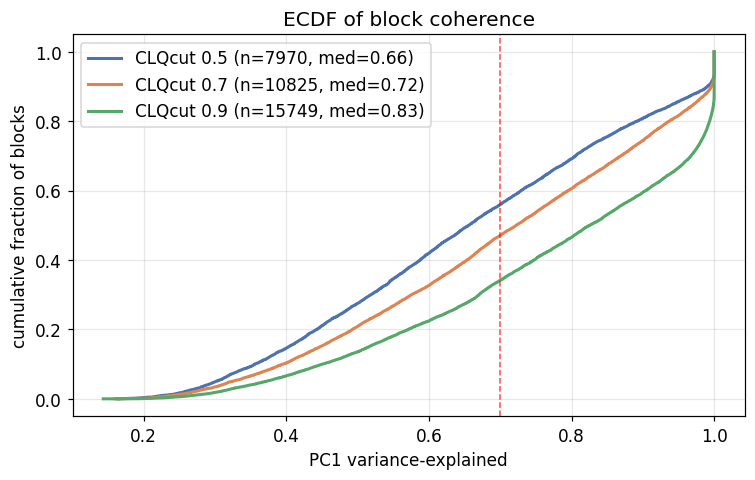

In [3]:
fig, ax = plt.subplots(figsize=(7,4.5))
for c in levels:
    v = np.sort(df[df.clqcut==c].pc1_ve.dropna().values)
    ax.plot(v, np.arange(1,len(v)+1)/len(v), color=colors[c], lw=2,
            label=f"CLQcut {c} (n={len(v)}, med={np.median(v):.2f})")
ax.axvline(0.7, ls="--", color="red", lw=1, alpha=.7)
ax.set_xlabel("PC1 variance-explained"); ax.set_ylabel("cumulative fraction of blocks")
ax.set_title("ECDF of block coherence"); ax.legend(); plt.tight_layout(); plt.show()

## 3. Summary: block count, median VE, %% coherent (VE≥0.7)

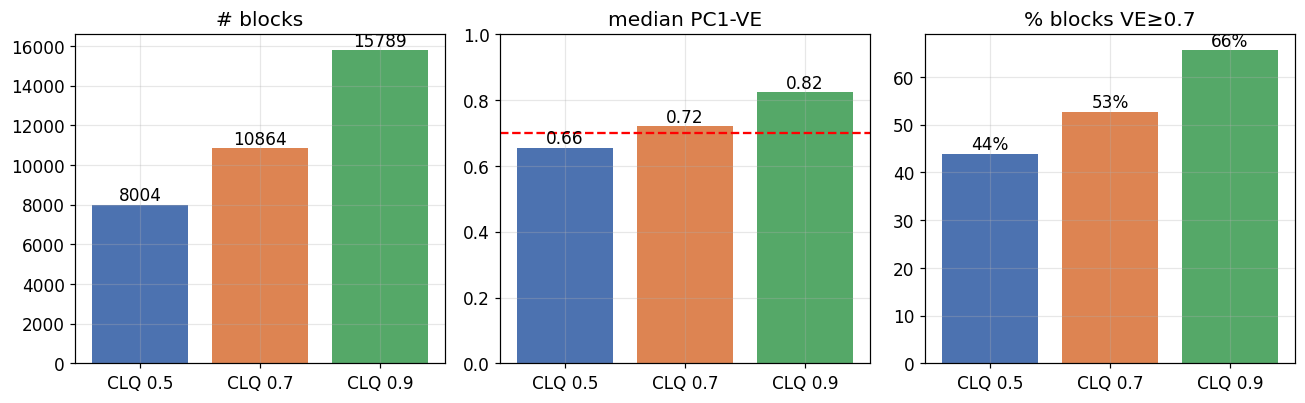

In [4]:
fig, axes = plt.subplots(1,3, figsize=(12,3.8))
x = range(len(levels)); cl=[colors[c] for c in levels]; lbl=[str(c) for c in levels]
axes[0].bar(x, summary.n_blocks, color=cl); axes[0].set_title("# blocks");
axes[1].bar(x, summary.median_VE, color=cl); axes[1].axhline(0.7,ls="--",color="red"); axes[1].set_title("median PC1-VE"); axes[1].set_ylim(0,1)
axes[2].bar(x, summary.frac_VE_ge_0p7*100, color=cl); axes[2].set_title("% blocks VE≥0.7")
for a in axes: a.set_xticks(list(x)); a.set_xticklabels([f"CLQ {l}" for l in lbl])
for i,c in enumerate(levels):
    axes[0].text(i, summary.n_blocks[c], f"{summary.n_blocks[c]}", ha="center", va="bottom")
    axes[1].text(i, summary.median_VE[c], f"{summary.median_VE[c]:.2f}", ha="center", va="bottom")
    axes[2].text(i, summary.frac_VE_ge_0p7[c]*100, f"{summary.frac_VE_ge_0p7[c]*100:.0f}%", ha="center", va="bottom")
plt.tight_layout(); plt.show()

## 4. PC1-VE vs block size (do bigger blocks lose coherence?)

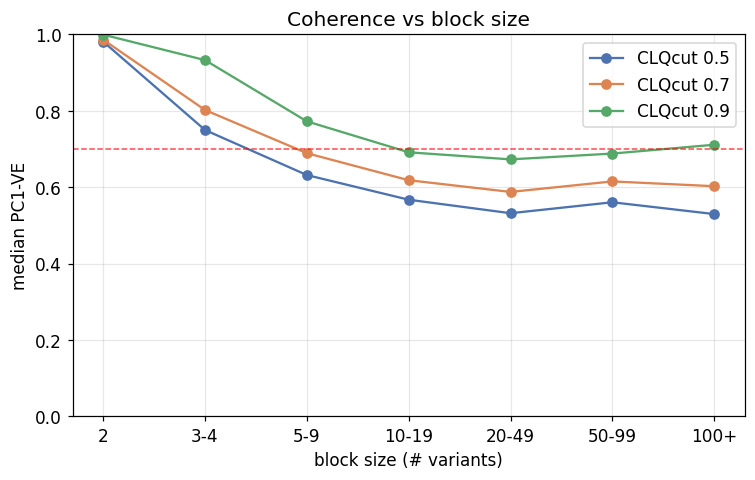

In [5]:
fig, ax = plt.subplots(figsize=(7,4.5))
bins = [2,3,5,10,20,50,100,1e6]; labs=["2","3-4","5-9","10-19","20-49","50-99","100+"]
for c in levels:
    d = df[(df.clqcut==c)&df.pc1_ve.notna()].copy()
    d["b"] = pd.cut(d.n_variants, bins, labels=labs, right=False)
    g = d.groupby("b", observed=True).pc1_ve.median()
    ax.plot(range(len(g)), g.values, "o-", color=colors[c], label=f"CLQcut {c}")
ax.axhline(0.7, ls="--", color="red", lw=1, alpha=.7)
ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs)
ax.set_xlabel("block size (# variants)"); ax.set_ylabel("median PC1-VE"); ax.set_ylim(0,1)
ax.set_title("Coherence vs block size"); ax.legend(); plt.tight_layout(); plt.show()

# Part B — the two stacked decisions: CLQcut (r²) × clustering gate

Coherence can be bought two ways, and they trade against the same currency (# test units):
1. **CLQcut** — tighter LD grouping → more, smaller blocks.
2. **Clustering gate** — split a block's founders into HapFM-xmeans haplotypes when its
   *effective* diversity n_eff exceeds a gate G → more, cleaner units.

A "unit" is what we run the selection test on: a whole block (if n_eff≤G) or each of its
signature-haplotype clusters (if n_eff>G). Per-unit PC1-VE is measured on the **gen9 pools**
(out-of-sample). We want the knee: **high coherence at the fewest units**.

In [6]:
BR = "/global/scratch/users/tbellg/kmate/results/grenenet_gea/blocks_mcf90"   # NON-MISSING (min-called-frac 0.9) Chr1 map
clqs = [c for c in [0.5,0.7,0.9] if os.path.exists(f"{BR}/chr1_frontier_blocks_clq{c}.csv")]
print("CLQcuts available:", clqs, "(0.5/0.7 appear once the clq_sweep job finishes)")
Bc = {c: pd.read_csv(f"{BR}/chr1_frontier_blocks_clq{c}.csv") for c in clqs}
Cc = {c: pd.read_csv(f"{BR}/chr1_frontier_clusters_clq{c}.csv") for c in clqs}
GATES = [("no-cluster", 1e9), ("gate 7", 7), ("gate 4", 4), ("gate 2", 2)]

def synth(clq, G):
    B = Bc[clq]; C = Cc[clq]
    bu = B[(B.n_eff <= G) & B.block_ve.notna()].block_ve.values          # block units
    cu = C[(C.n_eff > G) & C.cluster_ve.notna() &
           (C.n_sig_matched >= 2) & (C.cluster_freq >= 2/231)].cluster_ve.values  # cluster units
    ve = np.concatenate([bu, cu])
    return dict(clq=clq, gate=G, n_units=len(ve),
                median_VE=np.median(ve), frac_ge0p7=np.mean(ve >= 0.7))

front = pd.DataFrame([synth(c, g) for c in clqs for _, g in GATES])
front["gate_lbl"] = [lbl for c in clqs for lbl, _ in GATES]
front.round(3)

CLQcuts available: [0.5, 0.7, 0.9] (0.5/0.7 appear once the clq_sweep job finishes)


,clq,gate,n_units,median_VE,frac_ge0p7,gate_lbl
0,0.5,1.000000e+09,7970,0.656,0.440,no-cluster
1,0.5,7.000000e+00,10987,0.790,0.672,gate 7
2,0.5,4.000000e+00,11193,0.817,0.744,gate 4
3,0.5,2.000000e+00,11678,0.859,0.843,gate 2
4,0.7,1.000000e+09,10825,0.722,0.529,no-cluster
5,0.7,7.000000e+00,13473,0.818,0.703,gate 7
6,0.7,4.000000e+00,13845,0.850,0.776,gate 4
7,0.7,2.000000e+00,14609,0.893,0.883,gate 2
8,0.9,1.000000e+09,15749,0.825,0.658,no-cluster
9,0.9,7.000000e+00,17223,0.870,0.752,gate 7


## 5. The frontier — coherence vs # units (the decision plot)

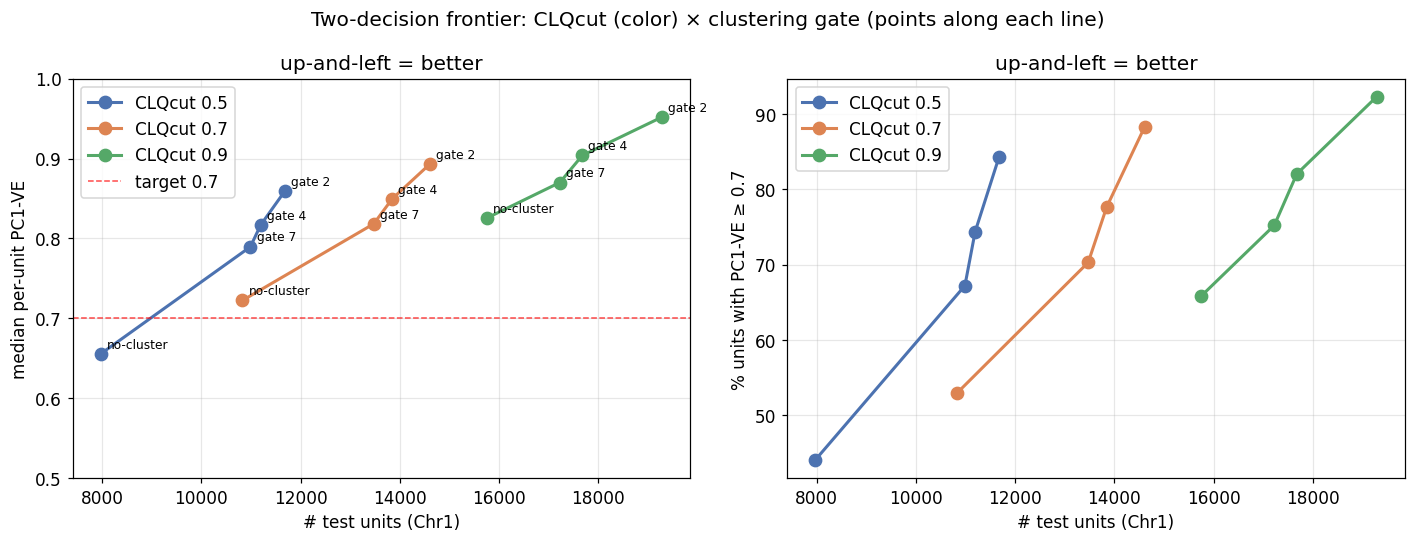

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for c in clqs:
    d = front[front.clq == c].sort_values("n_units")
    axes[0].plot(d.n_units, d.median_VE, "o-", color=colors[c], lw=2, ms=8, label=f"CLQcut {c}")
    axes[1].plot(d.n_units, d.frac_ge0p7*100, "o-", color=colors[c], lw=2, ms=8, label=f"CLQcut {c}")
    for _, r in d.iterrows():
        axes[0].annotate(r.gate_lbl, (r.n_units, r.median_VE), fontsize=8,
                         xytext=(4,4), textcoords="offset points")
axes[0].axhline(0.7, ls="--", color="red", lw=1, alpha=.7, label="target 0.7")
axes[0].set_ylabel("median per-unit PC1-VE"); axes[0].set_ylim(0.5,1.0)
axes[1].set_ylabel("% units with PC1-VE ≥ 0.7")
for a in axes:
    a.set_xlabel("# test units (Chr1)"); a.legend(); a.set_title("up-and-left = better")
plt.suptitle("Two-decision frontier: CLQcut (color) × clustering gate (points along each line)")
plt.tight_layout(); plt.show()

## 6. Per-unit coherence ECDF for candidate configs

Does clustering a *looser* map match a tight one? Compare the per-unit VE distributions.

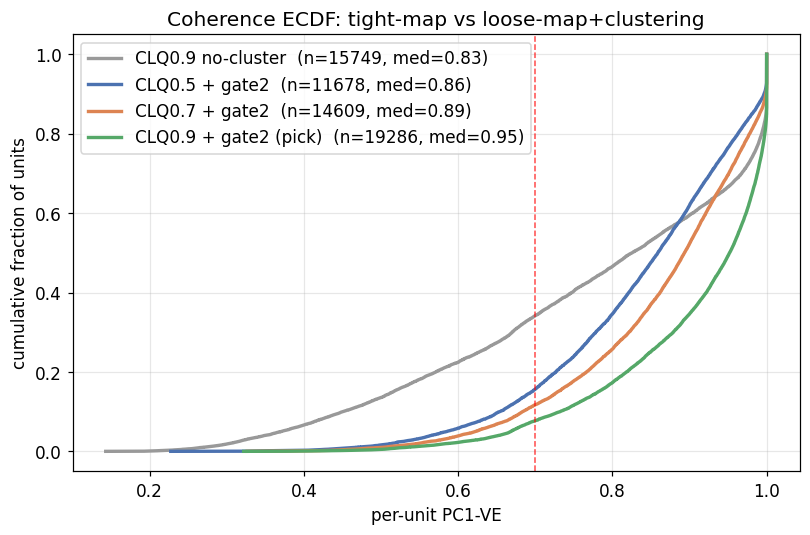

In [8]:
def units_ve(clq, G):
    B = Bc[clq]; C = Cc[clq]
    bu = B[(B.n_eff<=G)&B.block_ve.notna()].block_ve.values
    cu = C[(C.n_eff>G)&C.cluster_ve.notna()&(C.n_sig_matched>=2)&(C.cluster_freq>=2/231)].cluster_ve.values
    return np.sort(np.concatenate([bu, cu]))
configs = [(0.9, 1e9, "CLQ0.9 no-cluster", "#999999"),
           (0.5, 2, "CLQ0.5 + gate2", "#4C72B0"),
           (0.7, 2, "CLQ0.7 + gate2", "#DD8452"),
           (0.9, 2, "CLQ0.9 + gate2 (pick)", "#55A868")]
fig, ax = plt.subplots(figsize=(7.5,5))
for clq, G, lab, col in configs:
    if clq not in Bc: continue
    v = units_ve(clq, G)
    ax.plot(v, np.arange(1,len(v)+1)/len(v), color=col, lw=2.2,
            label=f"{lab}  (n={len(v)}, med={np.median(v):.2f})")
ax.axvline(0.7, ls="--", color="red", lw=1, alpha=.7)
ax.set_xlabel("per-unit PC1-VE"); ax.set_ylabel("cumulative fraction of units")
ax.set_title("Coherence ECDF: tight-map vs loose-map+clustering"); ax.legend()
plt.tight_layout(); plt.show()

# Part C — within-block trajectory divergence = recombination signal

Founder haplotypes are LD-welded in the panel. If a block's variants *diverge* in the
evolved pools (**evolved PC1-VE < founder PC1-VE**), the founder LD broke — over 9
generations the dominant cause is **recombination** (caveats: recurrent mutation,
genotyping error; selection can only separate linked variants *through* recombination).
These blocks are both recombination markers and **fine-mapping leads** (a recombinant that
splits a causal variant from its hitchhikers is what localizes the cause).

In [9]:
_fv = "/global/scratch/users/tbellg/kmate/results/grenenet_gea/blocks_mcf90/chr1_clq0.9_founder_vs_evolved_ve.csv"  # NON-MISSING map
rec = pd.read_csv(_fv) if os.path.exists(_fv) else pd.DataFrame(columns=["founder_ve","evolved_ve","eff_dim"])
rec["ve_drop"] = rec.founder_ve - rec.evolved_ve
margin = 0.2
cand = rec[rec.ve_drop > margin]
if len(rec):
    print(f"{len(rec)} blocks; median drop (founder-evolved VE) = {rec.ve_drop.median():+.3f}")
    print(f"LD-decay candidates (evolved_ve < founder_ve - {margin}): {len(cand)} ({100*len(cand)/len(rec):.1f}%)")
else:
    print("founder-vs-evolved not computed yet — re-run after clq_sweep job finishes")

15749 blocks; median drop (founder-evolved VE) = -0.006
LD-decay candidates (evolved_ve < founder_ve - 0.2): 72 (0.5%)


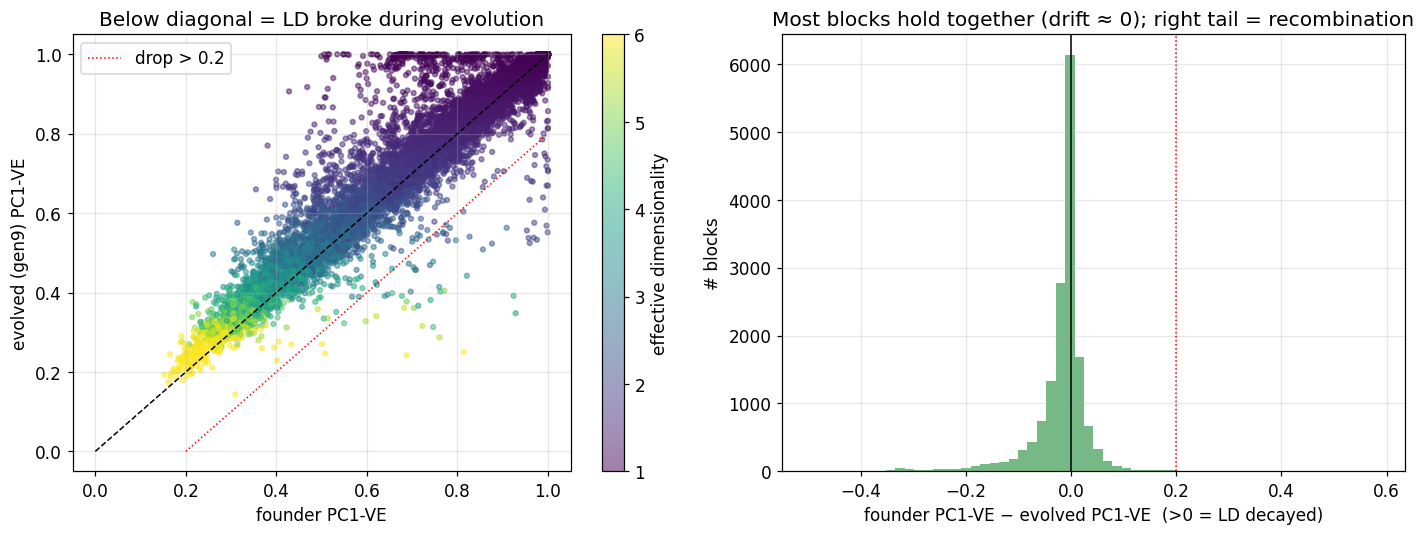

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc = axes[0].scatter(rec.founder_ve, rec.evolved_ve, c=rec.eff_dim, s=10,
                     cmap="viridis", alpha=.5, vmin=1, vmax=6)
axes[0].plot([0,1],[0,1], "k--", lw=1)
axes[0].plot([margin,1],[0,1-margin], "r:", lw=1, label=f"drop > {margin}")
plt.colorbar(sc, ax=axes[0], label="effective dimensionality")
axes[0].set_xlabel("founder PC1-VE"); axes[0].set_ylabel("evolved (gen9) PC1-VE")
axes[0].set_title("Below diagonal = LD broke during evolution"); axes[0].legend()
axes[1].hist(rec["ve_drop"].dropna(), bins=60, color="#55A868", alpha=.8)
axes[1].axvline(0, color="k", lw=1); axes[1].axvline(margin, color="r", ls=":", lw=1)
axes[1].set_xlabel("founder PC1-VE − evolved PC1-VE  (>0 = LD decayed)")
axes[1].set_ylabel("# blocks"); axes[1].set_title("Most blocks hold together (drift ≈ 0); right tail = recombination")
plt.tight_layout(); plt.show()

# Part D — panel-support redundancy filter (locked map: CLQ0.9 + gate2)

A variant with low **panel support** (founder call-rate from `var_called`) is poorly
*defined* → its haplotype assignment is shaky. But within a block it may be redundant:
if another, well-supported variant **tags the same haplotype-cluster**, dropping the
low-support one is lossless at haplotype resolution.

For each block variant we recorded (`block_panel_support_tag.py`): founder call-rate,
and the haplotype-cluster it tags (argmax founder-enrichment over the block's xmeans
clusters; single haplotype for n_eff≤2 blocks). Sweep a call-rate threshold X and ask:
of the variants we'd drop (call-rate < X), what fraction still have a **good-support
(≥X) tag-mate on the same haplotype** in their block ("safely droppable")?
*(Note: kMate AF has no per-pool missingness — n_finite≡355 — so panel support is the
only real per-variant support axis here.)*

In [11]:
import glob
_tf = sorted(glob.glob("/global/scratch/users/tbellg/kmate/results/grenenet_gea/blocks_recompute/chr*_panel_support_tag.csv"))
tag = pd.concat([pd.read_csv(f).assign(chrom=f.split("/")[-1].split("_")[0]) for f in _tf], ignore_index=True)
tag["grp"] = tag.groupby(["chrom","block","tag_cluster"]).ngroup()   # haplotype-unit id (per chrom)
tag["blk"] = tag.groupby(["chrom","block"]).ngroup()                 # whole-block id (per chrom)
print(f"panel-support tag: chroms {sorted(tag.chrom.unique())}, {len(tag):,} variants")
grp = tag.grp.values; cr = tag.call_rate.values; ng = grp.max()+1
Xs = np.round(np.arange(0.50, 1.001, 0.025), 3)
rows = []
for X in Xs:
    good = cr >= X
    has_good = np.bincount(grp, weights=good.astype(float), minlength=ng)[grp] >= 1
    dropped = ~good
    nd = dropped.sum()
    rescued = dropped & has_good
    rows.append(dict(X=X, pct_dropped=100*nd/len(cr),
                     pct_rescued=100*rescued.sum()/max(nd,1),
                     pct_net_lost=100*(dropped & ~has_good).sum()/len(cr)))
red = pd.DataFrame(rows)
print(red[red.X.isin([0.5,0.7,0.8,0.9,0.95,1.0])].round(1).to_string(index=False))

panel-support tag: chroms ['chr1', 'chr2', 'chr3', 'chr4', 'chr5'], 1,926,084 variants


  X  pct_dropped  pct_rescued  pct_net_lost
0.5          0.0          0.0           0.0
0.7          3.9         53.8           1.8
0.8         16.8         46.2           9.0
0.9         40.4         52.0          19.4
1.0         58.6         49.5          29.6
1.0         96.1         20.8          76.1


### How many haploblocks do we lose as we filter missingness?

The intuitive view: sweep the panel-support filter (drop variants with founder
call-rate < X) and count, **cumulatively**, how many *units* become untrackable —
i.e. every variant tagging that unit got filtered (so no surviving variant carries
its frequency). Two granularities: **haplotype units** (block × haplotype-cluster, our
actual test units) and **whole haploblocks** (a block lost only if *all* its variants
go). Both monotonic. Dashed grey = variants dropped (the input filter).

X=0.7: variants dropped  3.9% | haplotype units lost  1.9% (2,914) | whole blocks lost  2.4% (1,971)
X=0.8: variants dropped 16.8% | haplotype units lost  8.6% (13,344) | whole blocks lost  9.2% (7,523)
X=0.9: variants dropped 40.4% | haplotype units lost 24.2% (37,498) | whole blocks lost 21.8% (17,880)


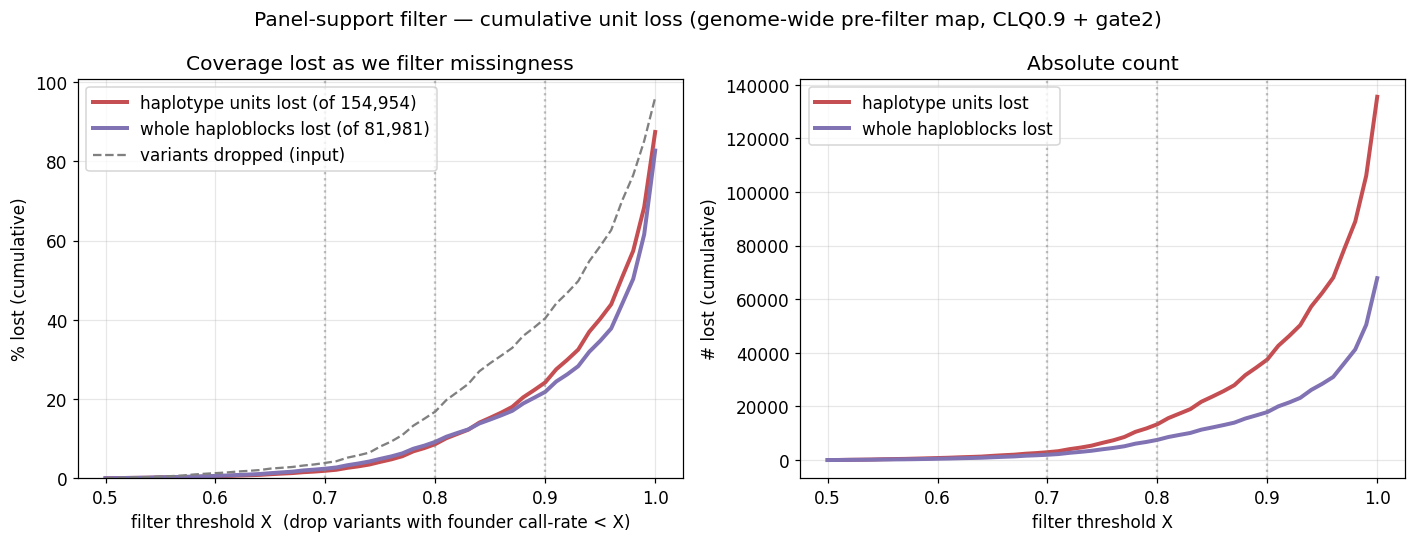

In [12]:
Xf = np.round(np.arange(0.50, 1.001, 0.01), 3)
gmax = tag.groupby("grp").call_rate.max().values          # per haplotype-unit, best support
bmax = tag.groupby("blk").call_rate.max().values          # per whole block
acr  = tag.call_rate.values
nU, nB, nV = len(gmax), len(bmax), len(acr)
units_lost  = np.array([(gmax < X).sum() for X in Xf])
blocks_lost = np.array([(bmax < X).sum() for X in Xf])
vars_dropped= np.array([(acr  < X).sum() for X in Xf])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(Xf, 100*units_lost/nU,  "-", color="#C44E52", lw=2.6, label=f"haplotype units lost (of {nU:,})")
axes[0].plot(Xf, 100*blocks_lost/nB, "-", color="#8172B3", lw=2.6, label=f"whole haploblocks lost (of {nB:,})")
axes[0].plot(Xf, 100*vars_dropped/nV,"--", color="grey",   lw=1.5, label="variants dropped (input)")
axes[0].set_xlabel("filter threshold X  (drop variants with founder call-rate < X)")
axes[0].set_ylabel("% lost (cumulative)"); axes[0].set_ylim(0,None)
axes[0].set_title("Coverage lost as we filter missingness"); axes[0].legend()
axes[1].plot(Xf, units_lost,  "-", color="#C44E52", lw=2.6, label="haplotype units lost")
axes[1].plot(Xf, blocks_lost, "-", color="#8172B3", lw=2.6, label="whole haploblocks lost")
axes[1].set_xlabel("filter threshold X"); axes[1].set_ylabel("# lost (cumulative)")
axes[1].set_title("Absolute count"); axes[1].legend()
for X0 in [0.7, 0.8, 0.9]:
    for ax in axes: ax.axvline(X0, ls=":", color="grey", alpha=.5)
    print(f"X={X0}: variants dropped {100*(acr<X0).mean():4.1f}% | "
          f"haplotype units lost {100*(gmax<X0).mean():4.1f}% ({(gmax<X0).sum():,}) | "
          f"whole blocks lost {100*(bmax<X0).mean():4.1f}% ({(bmax<X0).sum():,})")
plt.suptitle("Panel-support filter — cumulative unit loss (genome-wide pre-filter map, CLQ0.9 + gate2)")
plt.tight_layout(); plt.show()

## Why the filter isn't lossless: panel support is correlated *within* a haplotype

If a low-support variant always had a good-support sibling, the filter would be free.
It isn't — a poorly-genotyped haplotype tends to have *uniformly* low-support variants.
**Left:** within-haplotype call-rate spread is far tighter than a label-shuffled null
→ support clusters by haplotype. **Right:** so dropping at threshold X kills whole
*haplotypes* (not just redundant variants) — the haplotype-level coverage loss.

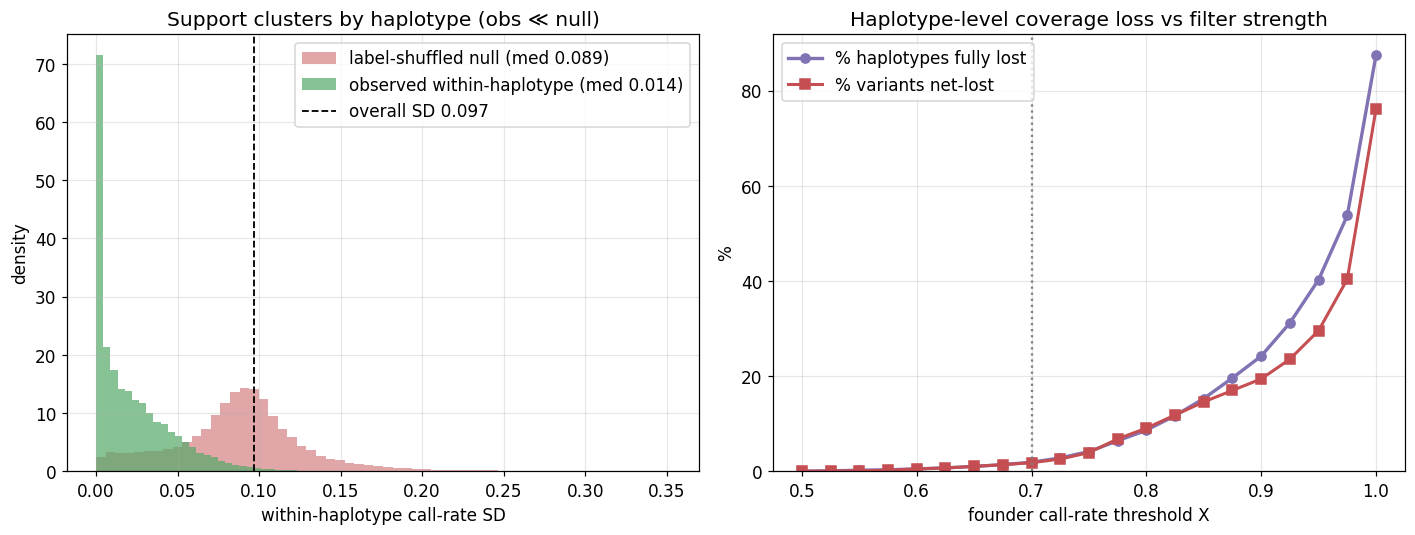

In [13]:
within_sd = tag.groupby("grp").call_rate.std().dropna()
rng = np.random.default_rng(0)
sh = tag.call_rate.values.copy(); rng.shuffle(sh); tag["_sh"] = sh
within_sd_null = tag.groupby("grp")._sh.std().dropna()
overall = tag.call_rate.std()
gmax = tag.groupby("grp").call_rate.max()
pct_haplo_lost = [100*(gmax < X).mean() for X in red.X]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(within_sd_null, bins=60, density=True, alpha=.5, color="#C44E52",
             label=f"label-shuffled null (med {within_sd_null.median():.3f})")
axes[0].hist(within_sd, bins=60, density=True, alpha=.7, color="#55A868",
             label=f"observed within-haplotype (med {within_sd.median():.3f})")
axes[0].axvline(overall, ls="--", color="k", lw=1.2, label=f"overall SD {overall:.3f}")
axes[0].set_xlabel("within-haplotype call-rate SD"); axes[0].set_ylabel("density")
axes[0].set_title("Support clusters by haplotype (obs ≪ null)"); axes[0].legend()
axes[1].plot(red.X, pct_haplo_lost, "o-", color="#8172B3", lw=2.2, label="% haplotypes fully lost")
axes[1].plot(red.X, red.pct_net_lost, "s-", color="#C44E52", lw=2, label="% variants net-lost")
axes[1].axvline(0.7, ls=":", color="grey"); axes[1].set_ylim(0,None)
axes[1].set_xlabel("founder call-rate threshold X"); axes[1].set_ylabel("%")
axes[1].set_title("Haplotype-level coverage loss vs filter strength"); axes[1].legend()
plt.tight_layout(); plt.show()

# Part E — did missing-data imputation distort the clusters?

The panel is imputed, two ways: blocks use **mean-imputation** (missing→column mean,
deflates LD) and clustering uses **major-imputation** (missing→major allele). Robustness
check (`block_missing_sensitivity.py`): re-cluster each multi-hap block with the SAME
algorithm but **masked co-called distance** (real allele over shared-called sites only,
no imputation), and compare to the imputed clustering via **adjusted Rand index** (cut
at the same k). ARI≈1 ⇒ imputation didn't matter; ARI dropping in low-call-rate blocks
⇒ imputation reshaped those clusters.

chroms loaded: 5
46734 multi-hap blocks; ARI imputed-vs-masked: median 0.737, %>=0.8 46%


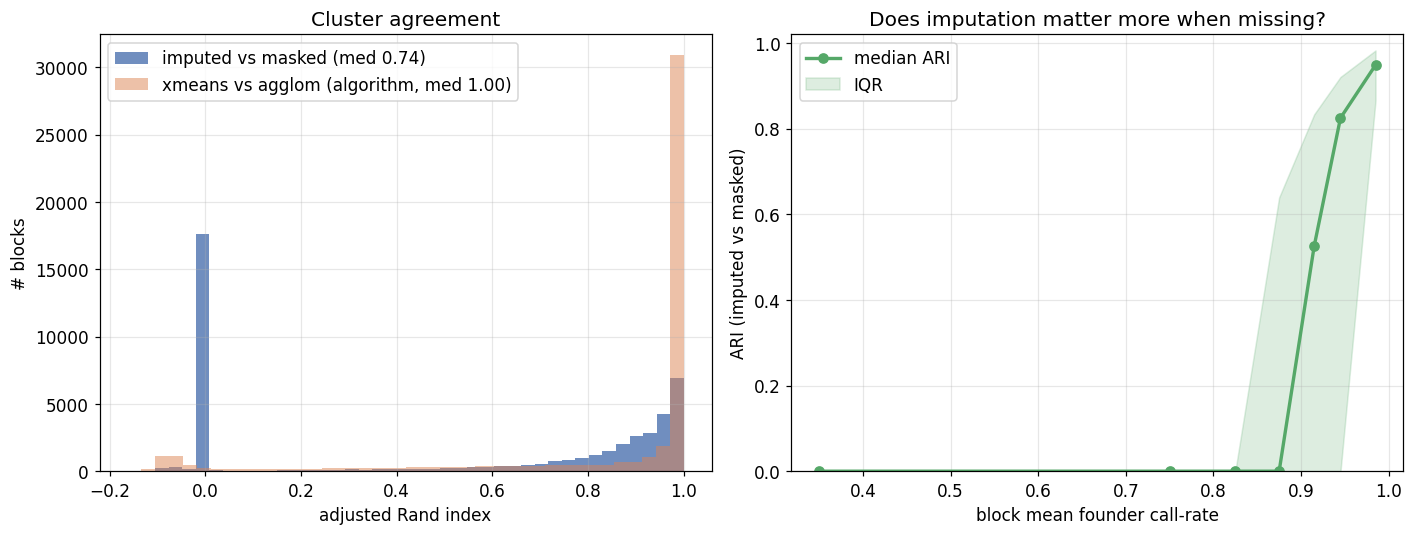

In [14]:
import glob
_msf = sorted(glob.glob("/global/scratch/users/tbellg/kmate/results/grenenet_gea/blocks_recompute/chr*_missing_sensitivity.csv"))
if not _msf:
    print("missing-sensitivity not computed yet — re-run after block_missing_sensitivity.py finishes")
else:
    ms = pd.concat([pd.read_csv(f) for f in _msf], ignore_index=True)
    print(f"chroms loaded: {len(_msf)}")
    print(f"{len(ms)} multi-hap blocks; ARI imputed-vs-masked: median {ms.ari_imp_vs_mask.median():.3f}, "
          f"%>=0.8 {100*(ms.ari_imp_vs_mask>=0.8).mean():.0f}%")
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].hist(ms.ari_imp_vs_mask, bins=40, color="#4C72B0", alpha=.8,
                 label=f"imputed vs masked (med {ms.ari_imp_vs_mask.median():.2f})")
    axes[0].hist(ms.ari_xm_vs_imp, bins=40, color="#DD8452", alpha=.5,
                 label=f"xmeans vs agglom (algorithm, med {ms.ari_xm_vs_imp.median():.2f})")
    axes[0].set_xlabel("adjusted Rand index"); axes[0].set_ylabel("# blocks")
    axes[0].set_title("Cluster agreement"); axes[0].legend()
    bins=[0,.7,.8,.85,.9,.93,.96,1.01]
    ms["cb"]=pd.cut(ms.mean_callrate, bins)
    g=ms.groupby("cb", observed=True).ari_imp_vs_mask
    mid=[i.mid for i in g.median().index]
    axes[1].plot(mid, g.median().values, "o-", color="#55A868", lw=2.2, label="median ARI")
    axes[1].fill_between(mid, g.quantile(.25).values, g.quantile(.75).values, color="#55A868", alpha=.2, label="IQR")
    axes[1].set_xlabel("block mean founder call-rate"); axes[1].set_ylabel("ARI (imputed vs masked)")
    axes[1].set_ylim(0,1.02); axes[1].set_title("Does imputation matter more when missing?"); axes[1].legend()
    plt.tight_layout(); plt.show()

# Part F — NEW 0.9 map: coherence & the PC1-VE threshold (decision 2)

After filtering variants at founder call-rate ≥ 0.9 and rebuilding blocks + haplotypes
(`blocks_mcf90`), these are the FINAL test units: each n_eff≤2 block = 1 unit (block AF),
each n_eff>2 block → its signature-haplotype clusters. Per-unit PC1-VE on the gen9 pools =
how single-trajectory each unit is. The right panel is the decision plot: requiring
PC1-VE ≥ T keeps the cleaner units and drops the rest.

In [15]:
MD = "/global/scratch/users/tbellg/kmate/results/grenenet_gea/blocks_mcf90"
bu_all, cu_all, neff_all = [], [], []
for ch in ["chr1","chr2","chr3","chr4","chr5"]:
    B = pd.read_csv(f"{MD}/{ch}_frontier_blocks_clq0.9.csv")
    C = pd.read_csv(f"{MD}/{ch}_frontier_clusters_clq0.9.csv")
    bu_all.append(B[(B.n_eff<=2)&B.block_ve.notna()].block_ve.values)
    cu_all.append(C[(C.n_eff>2)&C.cluster_ve.notna()&(C.n_sig_matched>=2)&(C.cluster_freq>=2/231)].cluster_ve.values)
    neff_all.append(B.n_eff.values)
bu=np.concatenate(bu_all); cu=np.concatenate(cu_all); ve=np.concatenate([bu,cu]); neff=np.concatenate(neff_all)
print(f"{len(ve):,} test units ({len(bu):,} biallelic-block + {len(cu):,} haplotype-cluster); "
      f"median per-unit PC1-VE {np.median(ve):.3f}")
for T in [0.6,0.7,0.8,0.9]:
    print(f"  require PC1-VE>={T}: keep {100*(ve>=T).mean():.1f}% ({(ve>=T).sum():,} units)")

71,624 test units (26,277 biallelic-block + 45,347 haplotype-cluster); median per-unit PC1-VE 0.951
  require PC1-VE>=0.6: keep 97.8% (70,026 units)
  require PC1-VE>=0.7: keep 92.2% (66,032 units)
  require PC1-VE>=0.8: keep 82.8% (59,273 units)
  require PC1-VE>=0.9: keep 65.2% (46,665 units)


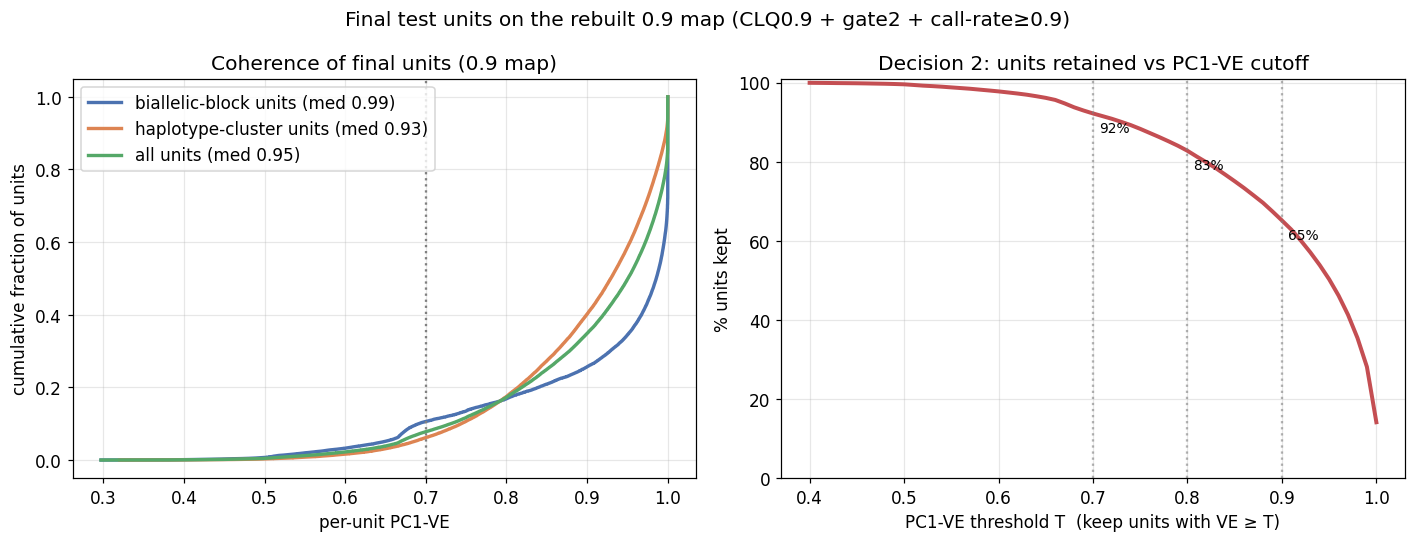

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
for v,lab,col in [(bu,"biallelic-block units","#4C72B0"),(cu,"haplotype-cluster units","#DD8452"),(ve,"all units","#55A868")]:
    s=np.sort(v); axes[0].plot(s, np.arange(1,len(s)+1)/len(s), color=col, lw=2.2, label=f"{lab} (med {np.median(v):.2f})")
axes[0].axvline(0.7, ls=":", color="grey"); axes[0].set_xlabel("per-unit PC1-VE")
axes[0].set_ylabel("cumulative fraction of units"); axes[0].set_title("Coherence of final units (0.9 map)"); axes[0].legend()
Ts=np.round(np.arange(0.4,1.001,0.01),3); kept=[100*(ve>=T).mean() for T in Ts]
axes[1].plot(Ts, kept, "-", color="#C44E52", lw=2.6)
for T0 in [0.7,0.8,0.9]:
    axes[1].axvline(T0, ls=":", color="grey", alpha=.6)
    axes[1].annotate(f"{(ve>=T0).mean()*100:.0f}%", (T0,(ve>=T0).mean()*100), fontsize=9, xytext=(4,-12), textcoords="offset points")
axes[1].set_xlabel("PC1-VE threshold T  (keep units with VE ≥ T)"); axes[1].set_ylabel("% units kept")
axes[1].set_title("Decision 2: units retained vs PC1-VE cutoff"); axes[1].set_ylim(0,101)
plt.suptitle("Final test units on the rebuilt 0.9 map (CLQ0.9 + gate2 + call-rate≥0.9)")
plt.tight_layout(); plt.show()